# 54 - CNN TL conf60 4-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNNTransfer
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "4class_tl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.00005
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class_tl


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionImageDataset(dataset_dir / f"X_{split}_images.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 58


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8267     0.7437     0.7372    0.8342   0.3837   0.000050  (18.4s)


     2      0.4226     0.9032     0.6272    0.8290   0.3228   0.000050  (18.1s)


     3      0.3039     0.9240     0.6077    0.8238   0.2972   0.000050  (18.2s)


     4      0.2234     0.9408     0.6049    0.8256   0.3028   0.000050  (18.2s)


...

    12      0.0181     0.9996     0.6689    0.8169   0.3278   0.000025  (18.2s)


    13      0.0162     0.9996     0.6809    0.8256   0.3302   0.000025  (18.2s)


    14      0.0142     0.9998     0.6990    0.8169   0.3314   0.000025  (18.2s)


    15      0.0131     1.0000     0.7270    0.8204   0.2913   0.000025  (18.3s)


    16      0.0122     0.9992     0.7162    0.8256   0.3089   0.000025  (18.2s)

Early stopping at epoch 16. Best epoch: 1 (val_f1=0.3837)

Best: epoch 1, val_acc=0.8342, val_f1=0.3837
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class_tl/cnn_tl_b1.pth


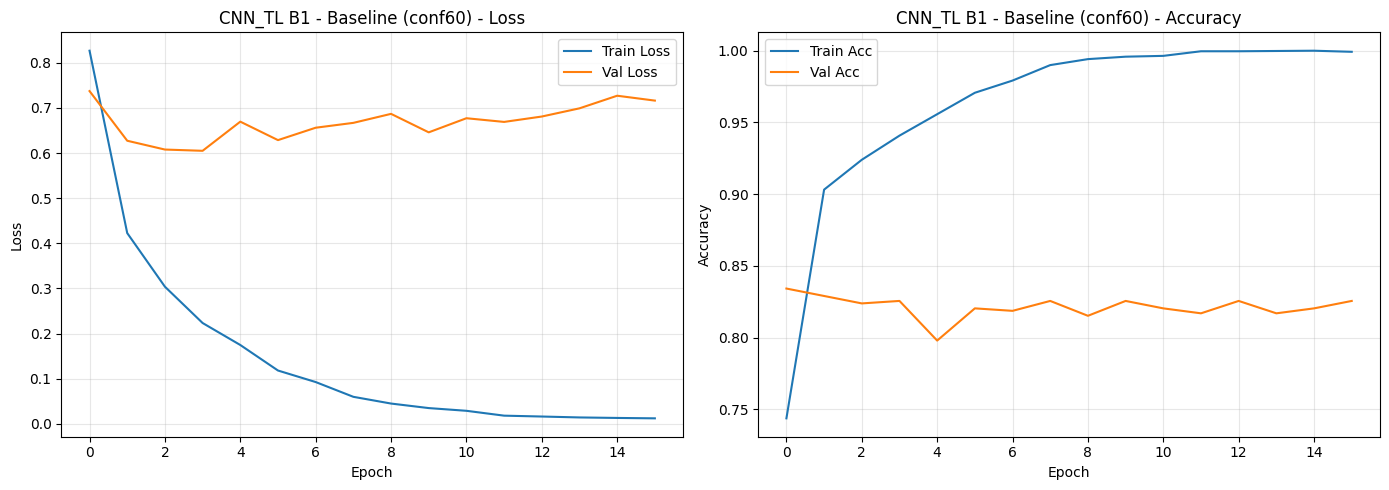

Test Loss: 0.8555
Test Accuracy: 0.7470
Test Macro F1: 0.4555
Test Weighted F1: 0.7597

Classification Report:
              precision    recall  f1-score   support

     neutral       0.92      0.78      0.84       688
       happy       0.47      0.77      0.58       183
         sad       0.39      0.40      0.40        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.75       929
   macro avg       0.45      0.49      0.46       929
weighted avg       0.79      0.75      0.76       929



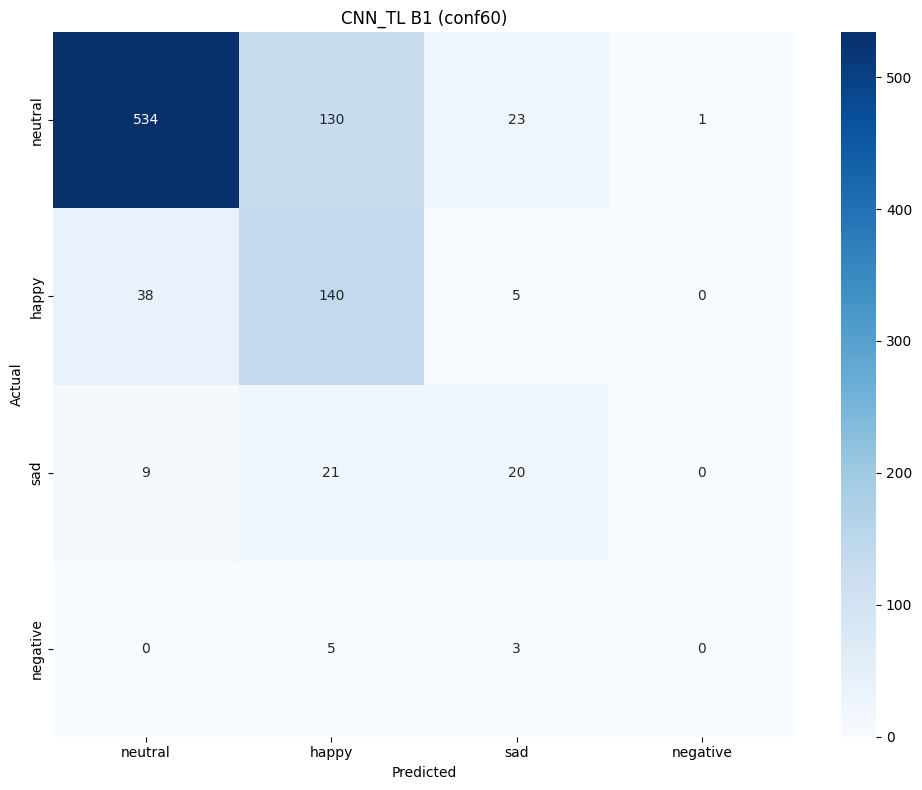

B1: Acc=0.7470 F1=0.4555

Class weights: None


Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8421     0.7297     0.7150    0.8307   0.3226   0.000050  (18.2s)


     2      0.4240     0.9075     0.6138    0.8342   0.3415   0.000050  (18.2s)


     3      0.2947     0.9238     0.5852    0.8307   0.3017   0.000050  (18.3s)


...

    13      0.0148     0.9994     0.7053    0.8256   0.2715   0.000025  (18.2s)


    14      0.0165     0.9991     0.6666    0.8273   0.2932   0.000025  (18.1s)


    15      0.0123     1.0000     0.7105    0.8238   0.2708   0.000025  (18.1s)


    16      0.0113     0.9996     0.7035    0.8256   0.2634   0.000025  (18.2s)


    17      0.0101     0.9998     0.7264    0.8221   0.2698   0.000025  (18.1s)

Early stopping at epoch 17. Best epoch: 2 (val_f1=0.3415)

Best: epoch 2, val_acc=0.8342, val_f1=0.3415
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class_tl/cnn_tl_b2.pth


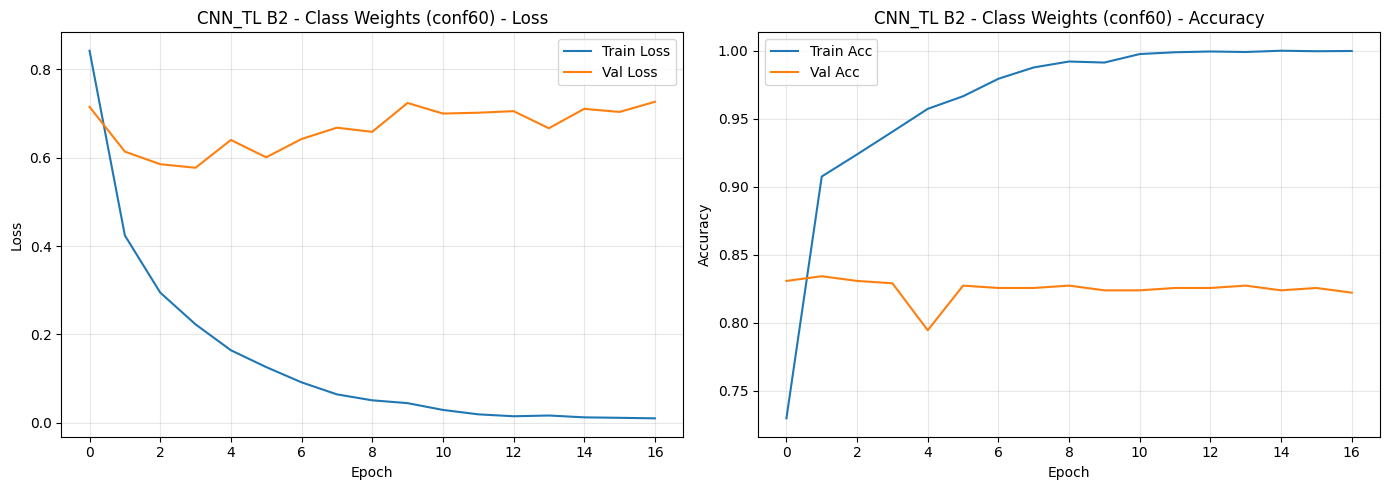

Test Loss: 0.8216
Test Accuracy: 0.7417
Test Macro F1: 0.4473
Test Weighted F1: 0.7483

Classification Report:
              precision    recall  f1-score   support

     neutral       0.87      0.81      0.84       688
       happy       0.50      0.58      0.54       183
         sad       0.34      0.52      0.41        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.74       929
   macro avg       0.43      0.48      0.45       929
weighted avg       0.76      0.74      0.75       929



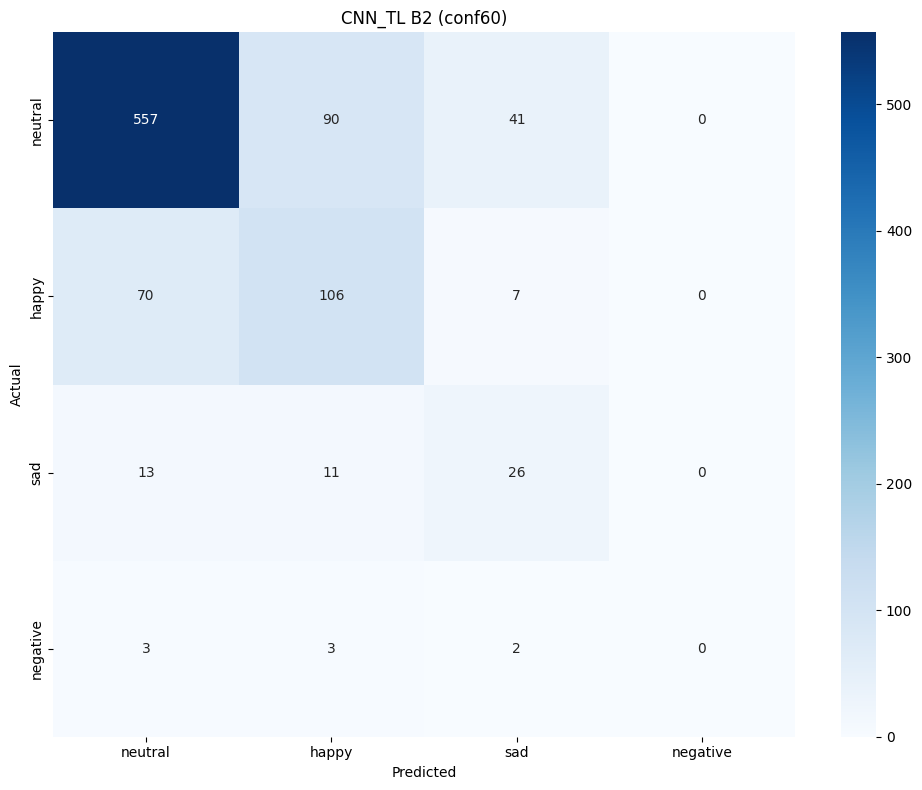

B2: Acc=0.7417 F1=0.4473


Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 600

Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8364     0.7432     0.7569    0.8152   0.3747   0.000050  (20.5s)


     2      0.3969     0.8988     0.6436    0.8273   0.3028   0.000050  (20.8s)


     3      0.2671     0.9333     0.5873    0.8290   0.3320   0.000050  (20.8s)


...

    17      0.0101     0.9995     0.6665    0.8152   0.3193   0.000025  (20.6s)


    18      0.0072     1.0000     0.7012    0.8238   0.2784   0.000025  (20.7s)


    19      0.0063     1.0000     0.6557    0.8204   0.3316   0.000025  (20.7s)


    20      0.0070     0.9995     0.6841    0.8152   0.2890   0.000025  (20.8s)


    21      0.0050     1.0000     0.6728    0.8238   0.3067   0.000025  (20.8s)

Early stopping at epoch 21. Best epoch: 6 (val_f1=0.3903)

Best: epoch 6, val_acc=0.8187, val_f1=0.3903
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class_tl/cnn_tl_b3.pth


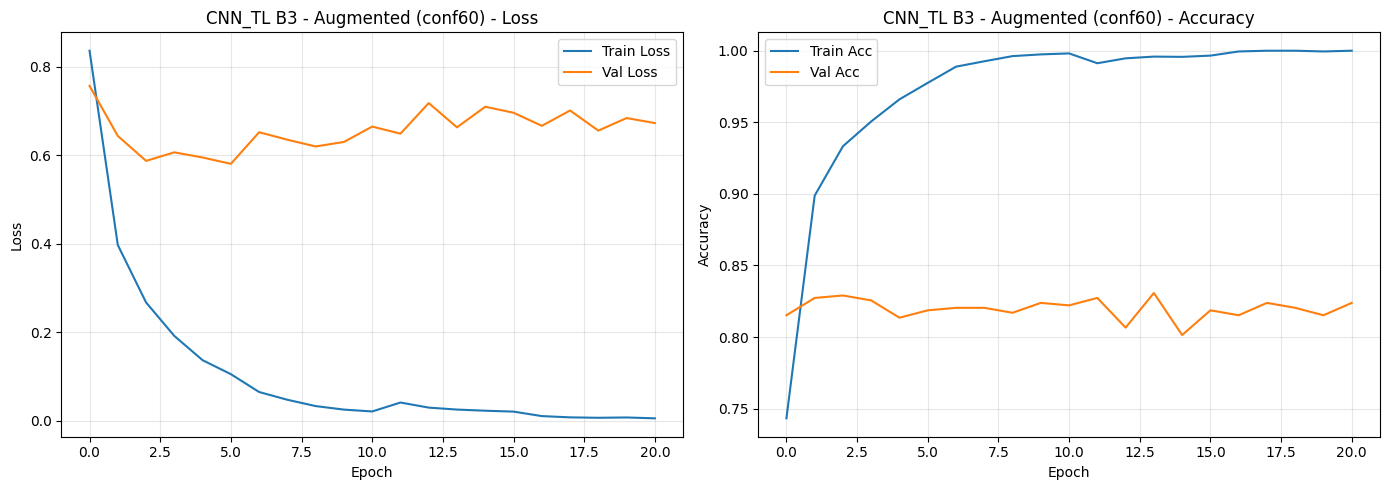

Test Loss: 0.6249
Test Accuracy: 0.7987
Test Macro F1: 0.5070
Test Weighted F1: 0.8071

Classification Report:
              precision    recall  f1-score   support

     neutral       0.92      0.82      0.87       688
       happy       0.62      0.80      0.70       183
         sad       0.38      0.58      0.46        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.80       929
   macro avg       0.48      0.55      0.51       929
weighted avg       0.83      0.80      0.81       929



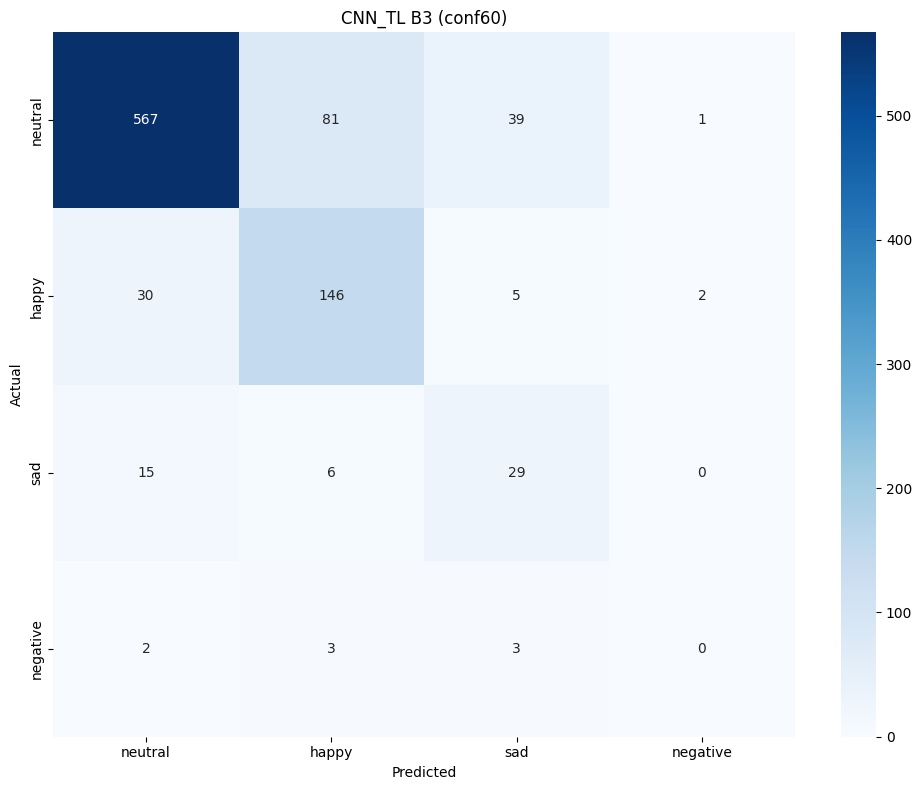

B3: Acc=0.7987 F1=0.5070

RINGKASAN CNN_TL (conf60)
  B1 Baseline               Acc=0.7470 F1=0.4555
  B2 Class Weights          Acc=0.7417 F1=0.4473
  B3 Weights+Aug            Acc=0.7987 F1=0.5070

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class_tl/cnn_tl_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_tl_b1.pth"))
plot_training_history(history_b1, "CNN_TL B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "CNN_TL B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_tl_b2.pth"))
plot_training_history(history_b2, "CNN_TL B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "CNN_TL B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = EmotionCNNTransfer(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_tl_b3.pth"))
plot_training_history(history_b3, "CNN_TL B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "cnn_tl_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "CNN_TL B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN CNN_TL (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "cnn_tl_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'cnn_tl_results.json'}")